In [14]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [15]:
import matplotlib
from matplotlib.image import NonUniformImage

In [16]:
from eryn.prior import uniform_dist

In [17]:
from bbhx.waveformbuild import BBHWaveformFD

In [18]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13


In [19]:
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity

In [20]:
# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer

In [21]:
merger_file="blackhole_mergers.hdf5"
merger_data=h5py.File(merger_file, 'r')
M_1=np.maximum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
M_2=np.minimum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
z=np.array(merger_data['time'])**(-1)-1

In [22]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value*1e6*PC_SI)

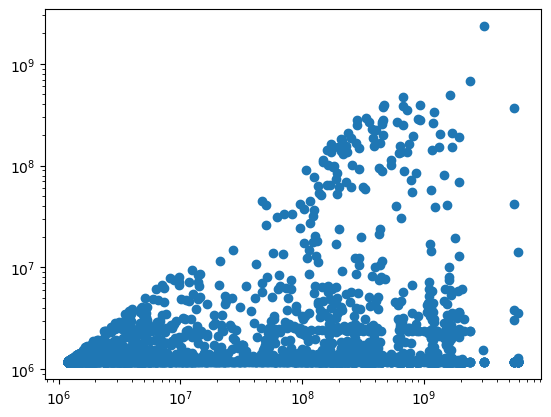

In [23]:
plt.loglog(M_1,M_2,'o')

In [24]:
#wave_gen = PhenomHMAmpPhase()

#parameters from simulation
#m1 = 2e6
#m2 = 7e5
#dist = 15 * 1e9 * PC_SI

#fixed parameters
#chi1 = 0.5
#chi2 = 0.7
#phi_ref = 0.6
#_ref = 0.0
#t_ref = 1e6 # seconds
#length = 1024

#wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)

In [25]:
""" m1 = M_1
m2 = M_2
dist = d_l
arr_size= len(m1)
chi1 = np.full(arr_size, 0.5)
chi2 = np.full(arr_size, 0.7)
phi_ref = np.full(arr_size, 0.6)
f_ref =  np.full(arr_size, 0.0)
inc =  np.full(arr_size, np.pi / 8)
lam =  np.full(arr_size, 0.5)
beta = np.full(arr_size, -0.7)
psi = np.full(arr_size, np.pi/4)
t_ref = np.full(arr_size, 1e6) # seconds

length = 1024

# setup data holders
Tobs = YRSID_SI/12   # 1 month
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt

freqs = np.fft.rfftfreq(N, dt)

#print(freqs)  """

' m1 = M_1\nm2 = M_2\ndist = d_l\narr_size= len(m1)\nchi1 = np.full(arr_size, 0.5)\nchi2 = np.full(arr_size, 0.7)\nphi_ref = np.full(arr_size, 0.6)\nf_ref =  np.full(arr_size, 0.0)\ninc =  np.full(arr_size, np.pi / 8)\nlam =  np.full(arr_size, 0.5)\nbeta = np.full(arr_size, -0.7)\npsi = np.full(arr_size, np.pi/4)\nt_ref = np.full(arr_size, 1e6) # seconds\n\nlength = 1024\n\n# setup data holders\nTobs = YRSID_SI/12   # 1 month\ndt = 10.0  # sec\nN = int(Tobs / dt)\nTobs = N * dt\n\nfreqs = np.fft.rfftfreq(N, dt)\n\n#print(freqs)  '

In [26]:
""" wave_AET=[]
for i in range(700):
    AET_gen = tdi_wave_gen(
        m1[i],
        m2[i], 
        chi1[i],
        chi2[i],
        dist[i], 
        phi_ref[i],
        f_ref[i], 
        inc[i],
        lam[i],
        beta[i],
        psi[i],
        t_ref[i],
        length=1024, 
        combine=False,  # TODO: check this
        direct=False,
        fill=True,
        squeeze=True,
        freqs=freqs
    )[0]
    wave_AET.append(AET_gen)
    #print(AET_gen)

    #print(AET.shape)
wave_AET=np.array(wave_AET)
#print(wave_AET.shape) """

' wave_AET=[]\nfor i in range(700):\n    AET_gen = tdi_wave_gen(\n        m1[i],\n        m2[i], \n        chi1[i],\n        chi2[i],\n        dist[i], \n        phi_ref[i],\n        f_ref[i], \n        inc[i],\n        lam[i],\n        beta[i],\n        psi[i],\n        t_ref[i],\n        length=1024, \n        combine=False,  # TODO: check this\n        direct=False,\n        fill=True,\n        squeeze=True,\n        freqs=freqs\n    )[0]\n    wave_AET.append(AET_gen)\n    #print(AET_gen)\n\n    #print(AET.shape)\nwave_AET=np.array(wave_AET)\n#print(wave_AET.shape) '

In [13]:
#print(wave_AET.shape)

In [40]:
arr_size = len(M_1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 1e6),
             num_elements = len(M_1)):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )[0]
        
        data = DataResidualArray(AET_gen, f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr)
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new


In [36]:
tdi_wave_gen = BBHWaveformFD()
def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc_opt(m1 = M_1, m2 = M_2, dist = d_l,n=1):
    arr_size=len(m1)*n
    m1new = []
    m2new = []
    distnew = []
    for i in range(len(m1)):
        m1new = m1new + [m1[i]]*n
        m2new = m2new + [m2[i]]*n
        distnew = distnew + [dist[i]]*n  

    chi1 = np.full(arr_size, 0.0)
    chi2 = np.full(arr_size, 0.0)    
    phi_ref = np.random.uniform(0.0, 2 * np.pi, arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(np.random.uniform(-1.0, 1.0,arr_size))
    lam = np.random.uniform(0.0, 2 * np.pi, arr_size)
    beta = np.arcsin(np.random.uniform(-1.0, 1.0,arr_size))
    psi = np.random.uniform(0.0,np.pi, arr_size)
    t_ref = np.full(arr_size, 1e6)

    # Setup data holders
    Tobs = YRSID_SI / 12   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)


    SNR_new = []

    for i in range(arr_size):
        AET_gen = tdi_wave_gen(
            m1new[i],
            m2new[i], 
            chi1[i],
            chi2[i],
            distnew[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )[0]
        
        data = DataResidualArray(AET_gen, f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr)
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)
        
    result={
        'm1'  :m1new,
        'm2'  :m2new,
        'dist' : distnew,
        'chi1':chi1,
        'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'snr':SNR_new
    }
    return result


In [39]:
SNR_calc_opt(m1=M_1,m2=M_1,dist=d_l,n=1)

/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

{'m1': [1203136.9484784503,
  1245180.1468995747,
  1473060.2607861324,
  3679273.6796094123,
  3261824.687645895,
  1404478.936064312,
  1354715.1023714498,
  1194208.7018772727,
  1316087.9735688888,
  1319304.6901119882,
  1257453.4650681943,
  1297049.002991651,
  1223432.2945533718,
  1492559.8057101315,
  1234803.6904296041,
  1220246.512108189,
  2526144.170844919,
  1305894.543844926,
  1260166.8580597723,
  1420742.5380440757,
  1300808.9996294146,
  1325549.188898758,
  1429108.3855595158,
  3162710.3341795593,
  3637968.4957257407,
  3803469.356702674,
  4705860.816241454,
  1800118.1000757304,
  5083436.830090824,
  2988204.858047216,
  1249140.7855335488,
  1207677.923678551,
  1245137.2902847526,
  3130838.5464196443,
  4486019.915871153,
  1245633.3099520437,
  2878757.0121357944,
  1380271.608113598,
  2818703.831533415,
  6708104.6751270015,
  1686005.327752416,
  1258585.7819440241,
  1330448.8062965819,
  8198833.461506619,
  1464441.999624496,
  1470289.2960012092,


In [41]:
def draw_params(m1 = M_1, m2 = M_2, dist = d_l,n=1): 
                
    arr_size=len(m1)*n
    m1new = []
    m2new = []
    distnew = []
    for i in range(len(m1)):
        m1new = m1new + [m1[i]]*n
        m2new = m2new + [m2[i]]*n
        distnew = distnew + [dist[i]]*n  

    chi1 = np.full(arr_size, 0.0)
    chi2 = np.full(arr_size, 0.0)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
        'm1'  :m1new,
        'm2'  :m2new,
        'dist' : distnew,
        'chi1':chi1,
        'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

In [37]:
# Calling the function
#snr_tng50 = SNR_calc()

In [44]:
p=draw_params(m1 = M_1, m2 = M_2, dist = d_l,n=1)

In [45]:
snr_tng50_params_5=SNR_calc(**p)

In [48]:
#print(snr_tng50)
#np.save('snr_tng50_params_5.npy', snr_tng50_params_5)

In [14]:
""" with h5py.File('wave_AET.h5', 'w') as hdf_file:
    hdf_file.create_dataset('wave_AET', data=wave_AET) """

In [16]:
""" fn = np.logspace(-6, -1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")
plt.loglog(fn, Sn_char_strain)
plt.loglog(freqs, freqs * np.abs(wave_AET[0,1]),label='A')
plt.loglog(freqs, freqs * np.abs(wave_AET[1,1]),label='E')
plt.loglog(freqs, freqs * np.abs(wave_AET[2,1]), label='T')
plt.legend() """

' fn = np.logspace(-6, -1, 10000)\nSn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")\nplt.loglog(fn, Sn_char_strain)\nplt.loglog(freqs, freqs * np.abs(wave_AET[0,1]),label=\'A\')\nplt.loglog(freqs, freqs * np.abs(wave_AET[1,1]),label=\'E\')\nplt.loglog(freqs, freqs * np.abs(wave_AET[2,1]), label=\'T\')\nplt.legend() '

In [18]:
#wave_AET= np.load('wave_AET.npy')


In [17]:
""" snr_tng50=[]
for i in range(700):
    data = DataResidualArray(wave_AET[i], f_arr=freqs)
    sens_mat = AET1SensitivityMatrix(data.f_arr)
    analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
    snr=analysis.snr()
    snr_tng50.append(snr)
    #print(snr_tng50)
 """

In [39]:
#snr_tng50=analysis.snr()
#np.save('snr_tng50.npy', snr_tng50)

In [33]:
snr_tng50=np.load('snr_tng50.npy')
snr_tng50_params=np.load('snr_tng50_params.npy')
snr_tng50_params_5=np.load('snr_tng50_params_5.npy')
snr_tng50_old=np.load('snr_tng_50_old.npy')

In [34]:
print(snr_tng50_params)

[5.98272142e+02 5.86754920e+02 2.56982610e+02 ... 4.45234237e+04
 1.40701041e+07 5.77344877e+04]


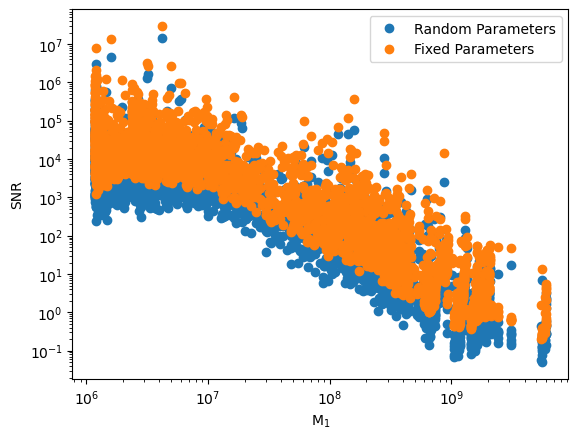

In [18]:
plt.loglog(M_1,snr_tng50_params,'o',label='Random Parameters')
plt.loglog(M_1,snr_tng50,'o',label='Fixed Parameters')
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()

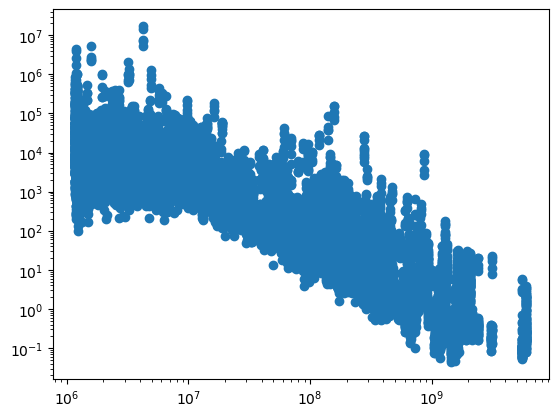

In [21]:
M_1_new=p['m1']
M_2_new=p['m2']
plt.loglog(M_1_new,snr_tng50_params_5,'o',label='Random Parameters')

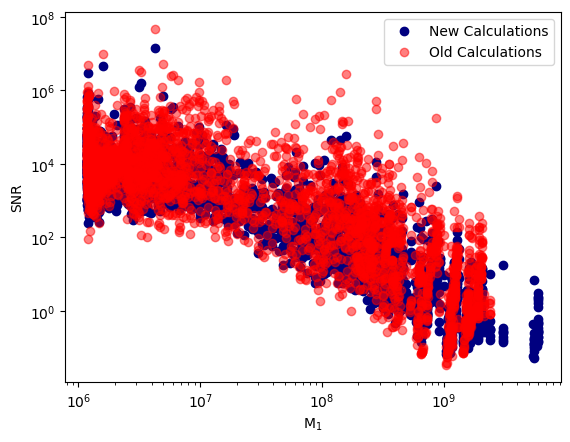

In [22]:
plt.loglog(M_1,snr_tng50_params,'o',label='New Calculations',c='navy')
plt.loglog(M_1,snr_tng50_old,'o',label='Old Calculations', c='red',alpha=.5)
plt.xlabel('M$_1$')
plt.ylabel('SNR')
plt.legend()

In [23]:
def avg_hist(x,y,z, bins=(20,20), c1='Spectral', c2= 'Spectral',  labelx=None, labely=None,
            labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, 
            norm2=None, vmin=None,vmax=None):
 #            norm2=matplotlib.colors.LogNorm(vmin=None, vmax=None) ):
    z_mask=((~np.isnan(z))&(~np.isnan(x))&(~np.isnan(y)))
    x=x[z_mask]
    y=y[z_mask]
    z=z[z_mask]
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    if logweight:
        z=np.log10(z)
    H_z, xedges, yedges = np.histogram2d(x,y, bins=(xedges, yedges), weights=z)
    H_num=H_num.T
    H_z=H_z.T
    plt.figure(figsize=(15,10))
    plt.subplot(2, 1, 1)
    plt.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           cmap= c1, norm=norm1)
 
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label='Numbers')

    plt.subplot(2,1,2)
    plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax,vmin=vmin)
    #print(np.min(H_z/H_num), np.max(H_z/H_num))
    #print(H_z/H_num)
   
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label=labelz)
   
    
    plt.tight_layout()
    plt.gca().set_aspect('equal')


/tmp/ipykernel_1636/2742178974.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


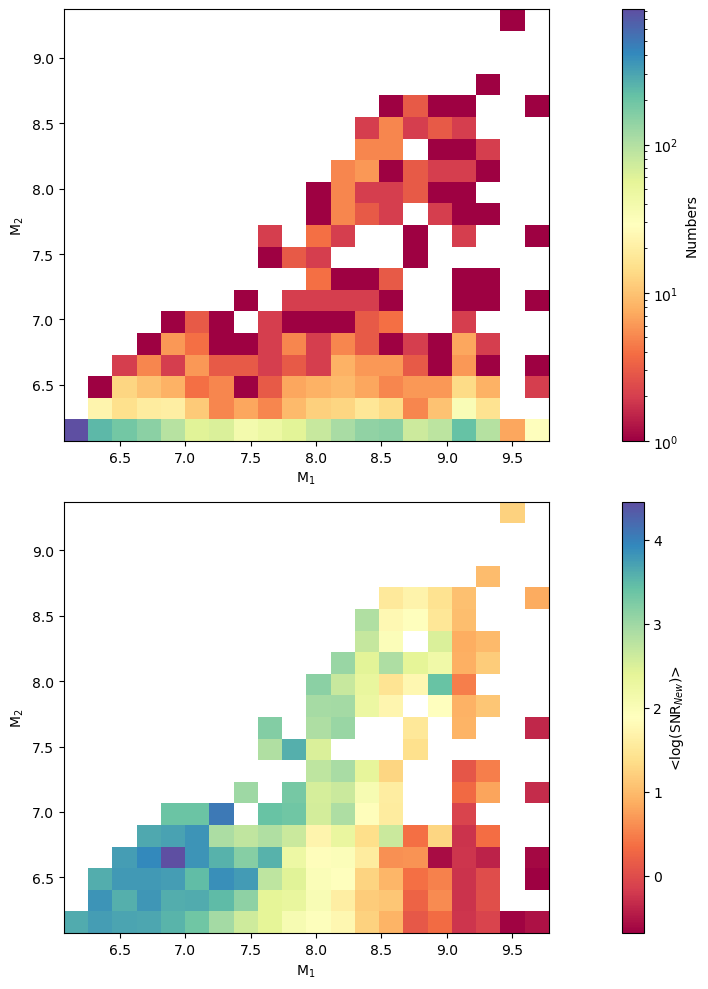

In [24]:
avg_hist(np.log10(M_1), np.log10(M_2),snr_tng50_params,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR$_{New}$)>', logweight=True)

/tmp/ipykernel_1636/2742178974.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


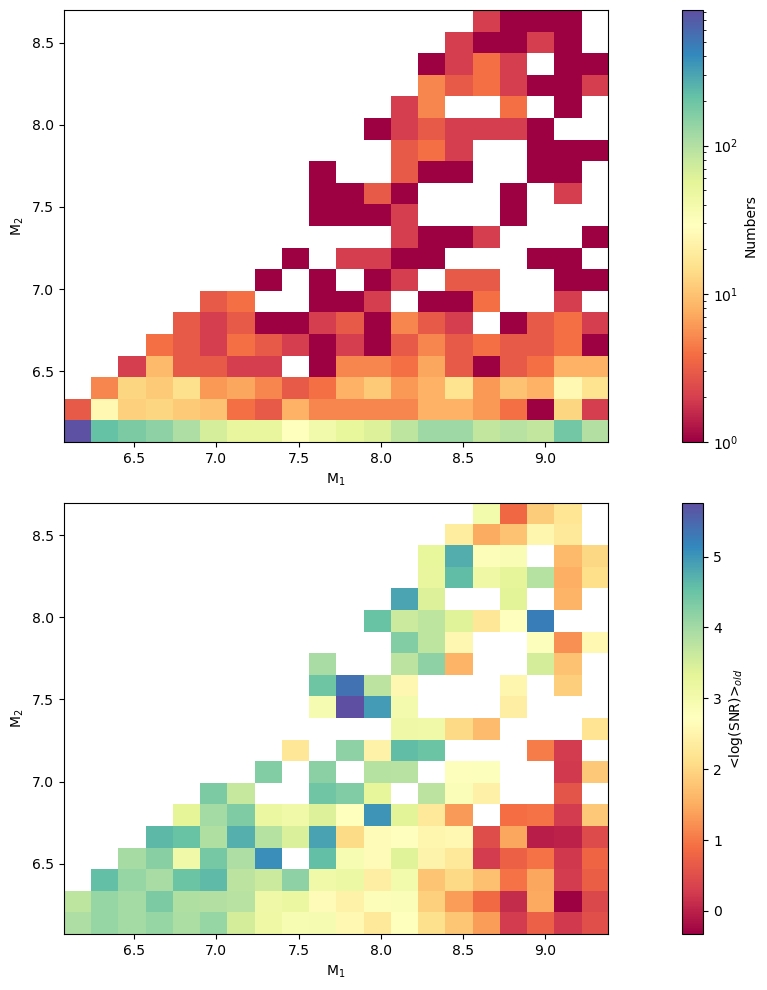

In [25]:
avg_hist(np.log10(M_1), np.log10(M_2),snr_tng50_old,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR)>$_{old}$', logweight=True)

/tmp/ipykernel_1636/2742178974.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


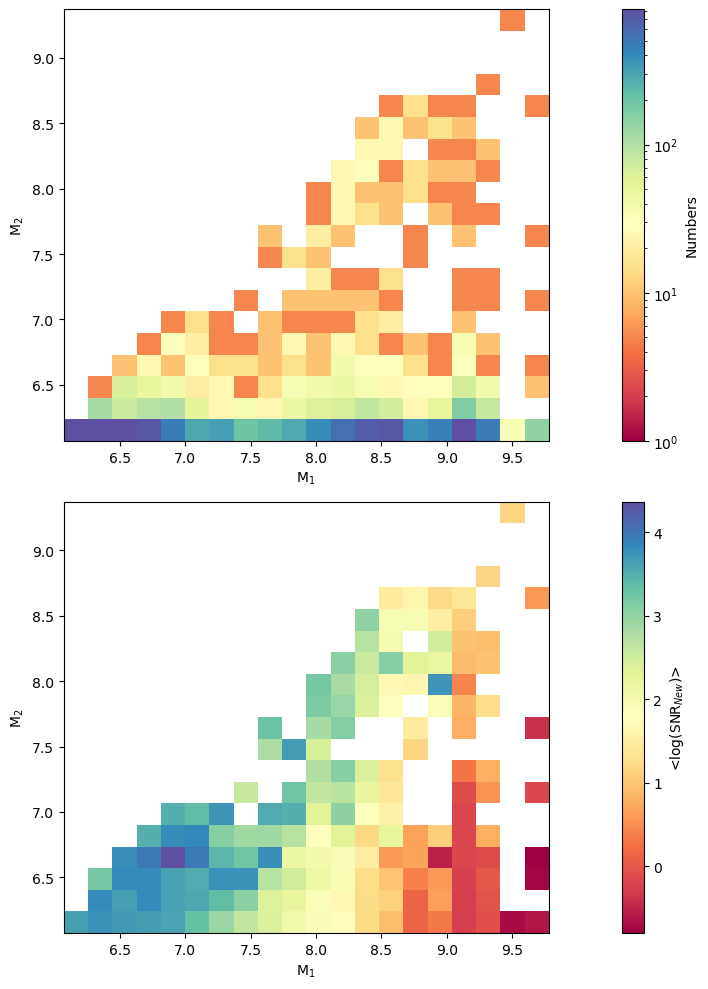

In [26]:
avg_hist(np.log10(M_1_new), np.log10(M_2_new),snr_tng50_params_5,labelx='M$_1$',labely='M$_2$',labelz='<log(SNR$_{New}$)>', logweight=True)